## Exploratory Data Analysis and KPI 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

customers = pd.read_csv("../data/processed/Customers.csv")
orders = pd.read_csv("../data/processed/Orders.csv")
order_items = pd.read_csv("../data/processed/Order_items.csv")
products = pd.read_csv("../data/processed/Products.csv")
shipping = pd.read_csv("../data/processed/Shipping.csv")
stores = pd.read_csv("../data/processed/Stores.csv")
store_depts = pd.read_csv("../data/processed/Store_departments.csv")

print(customers.head())
print(orders.head())
print(order_items.head())
print(products.head())
print(shipping.head())
print(store_depts.head())
print(stores.head())

   Customer_id Customer_fname Customer_lname Customer_email Customer_password  \
0        20755          Cally       Holloway      XXXXXXXXX         XXXXXXXXX   
1        19492          Irene           Luna      XXXXXXXXX         XXXXXXXXX   
2        19491        Gillian      Maldonado      XXXXXXXXX         XXXXXXXXX   
3        19490           Tana           Tate      XXXXXXXXX         XXXXXXXXX   
4        19489           Orli      Hendricks      XXXXXXXXX         XXXXXXXXX   

  Customer_country Customer_state Customer_city           Customer_street  \
0      Puerto Rico             PR        Caguas  5365 Noble Nectar Island   
1      Puerto Rico             PR        Caguas          2679 Rustic Loop   
2          EE. UU.             CA      San Jose      8510 Round Bear Gate   
3          EE. UU.             CA   Los Angeles           3200 Amber Bend   
4      Puerto Rico             PR        Caguas  8671 Iron Anchor Corners   

   Customer_zipcode Customer_segment  
0          

## Table Analysis

| Table             | Key Columns           | Purpose                                            |
| ----------------- | --------------------- | -------------------------------------------------- |
| Customers         | customer_id           | Info about customer region, type                   |
| Orders            | order_id, customer_id | Main table with order details                      |
| Order_items       | order_id, product_id  | Items in each order, quantity, price               |
| Products          | product_id            | Product category, brand, etc.                      |
| Shipping          | order_id              | Shipping mode, days to deliver, late delivery info |
| Stores            | store_id              | Store location info                                |
| Store_departments | store_id, dept_id     | Which departments exist in each store              |


In [3]:
# Merging datasets

#### Merge Orders with Shipping (to get Y variable)
df = orders.merge(shipping[['Order_id', 'Late_delivery_risk', 'Days_for_shipping', 'Days_for_shipment', 'Shipping_mode']], on='Order_id', how='left')

# Merging Order_items to get product info
df = df.merge(order_items, on='Order_id', how='left')

# Merging Products to get product category / price
df = df.merge(products, on='Product_card_id', how='left')

# Merging Customers to get customer region / type
df = df.merge(customers, on='Customer_id', how='left')

# Merging Stores if store_location is needed
df = df.merge(stores, on='Store_id', how='left')


# Cleaning Y variable

# Making sure Late_delivery_risk is numeric 0/1
df['Late_delivery_risk'] = pd.to_numeric(df['Late_delivery_risk'], errors='coerce')
df = df.dropna(subset=['Late_delivery_risk'])
df['Late_delivery_risk'] = df['Late_delivery_risk'].astype(int)


# Checking dataset overview

print("Dataset shape:", df.shape)
print(df.info())
print(df.describe())


Dataset shape: (180519, 43)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 43 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Order_id                  180519 non-null  int64  
 1   Customer_id               180519 non-null  int64  
 2   Store_id                  180519 non-null  int64  
 3   Order_date                180519 non-null  object 
 4   Order_region              180519 non-null  object 
 5   Market                    180519 non-null  object 
 6   Order_country             180519 non-null  object 
 7   Order_state               180519 non-null  object 
 8   Order_city                180519 non-null  object 
 9   Order_zipcode             24840 non-null   float64
 10  Delivery_status           180519 non-null  object 
 11  Order_status              180519 non-null  object 
 12  Payment_method            180519 non-null  object 
 13  Order_total     

In [4]:
# DROPPING SENSITIVE/USELESS COLUMNS

cols_to_drop = ['Customer_password', 'Customer_email', 'Customer_street', 'Customer_fname', 'Customer_lname', 'Product_image']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
# Dropping order_zipcode due to 80% missing values
df = df.drop(columns=['Order_zipcode'])

# CONVERTING DATES
# Ensuring dates are actual datetime objects so we can extract time-based insights
pd.to_datetime(df['Order_date'], format='%d-%m-%y %H:%M')

0        2018-01-31 22:56:00
1        2018-01-13 12:27:00
2        2018-01-13 12:06:00
3        2018-01-13 11:45:00
4        2018-01-13 11:24:00
                 ...        
180514   2016-01-22 06:49:00
180515   2016-01-21 02:47:00
180516   2016-01-21 02:47:00
180517   2016-01-20 07:10:00
180518   2016-01-17 05:56:00
Name: Order_date, Length: 180519, dtype: datetime64[ns]

In [5]:
#shipping

#checking for missing values
print(shipping['Late_delivery_risk'].isnull().sum()) # no missing values found

0


#### Missing Values Summary

In [24]:
df.isnull().sum()
df.duplicated().sum()
df.describe()

,Order_id,Customer_id,Store_id,Order_total,Late_delivery_risk,Days_for_shipping,Days_for_shipment,Order_item_id,Product_card_id,Order_item_quantity,...,Order_item_total,Product_status,Product_price,Customer_zipcode,Latitude,Longitude,Order_item_profit,Delivery_Gap,Profit_Margin,order_date
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,...,180519.000000,180519.0,180519.000000,180516.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519
mean,36221.894903,6691.379495,7447.655072,638.185860,0.548291,3.497654,2.931847,90260.000000,692.509764,2.127638,...,183.107609,0.0,141.232550,35921.126914,29.719955,-84.915675,22.010661,-0.565807,0.120647,2016-06-15 17:09:59.086966016
min,1.000000,1.000000,1.000000,7.490000,0.000000,0.000000,0.000000,1.000000,19.000000,1.000000,...,7.490000,0.0,9.990000,603.000000,-33.937553,-158.025986,-4274.977478,-4.000000,-2.750000,2015-01-01 00:00:00
25%,18057.000000,3258.500000,4959.000000,409.480011,0.000000,2.000000,2.000000,45130.500000,403.000000,1.000000,...,104.379997,0.0,50.000000,725.000000,18.265432,-98.446312,7.054200,-1.000000,0.080000,2015-09-20 17:51:00
50%,36140.000000,6457.000000,8311.000000,632.320007,1.000000,3.000000,4.000000,90260.000000,627.000000,1.000000,...,163.990005,0.0,59.990002,19380.000000,33.144863,-76.847908,31.665199,-1.000000,0.270000,2016-06-11 13:56:00
75%,54144.000000,9779.000000,10212.000000,851.779999,1.000000,5.000000,4.000000,135389.500000,1004.000000,3.000000,...,247.399994,0.0,199.990005,78207.000000,39.279617,-66.370583,64.798201,0.000000,0.360000,2017-03-03 13:25:30
max,77204.000000,20757.000000,11835.000000,2768.409988,1.000000,6.000000,4.000000,180519.000000,1363.000000,5.000000,...,1939.989990,0.0,1999.989990,99205.000000,48.781933,115.263077,911.795293,2.000000,0.500000,2018-12-01 23:51:00
std,21045.379569,4162.918106,3338.168227,309.256594,0.497664,1.623722,1.374449,52111.490959,336.446807,1.453451,...,120.043670,0.0,139.732492,37542.461122,9.813646,21.433241,104.467036,1.490966,0.466796,NaN


## Feature Engineering

In [7]:
# 1. Absolute profit amount 
df['Order_item_profit'] = df['Order_item_total'] * df['Order_item_profit_ratio']

# 2. Delivery Gap (Actual - Scheduled)
df['Delivery_Gap'] = df['Days_for_shipment'] - df['Days_for_shipping']

# 3. Profit Margin percentage
df['Profit_Margin'] = df['Order_item_profit'] / df['Order_item_total']

# 4. Time-based features
df['order_date'] = pd.to_datetime(df['Order_date']) 
df['Order_Day'] = df['order_date'].dt.day_name()
df['Order_Month'] = df['order_date'].dt.month_name()

C:\Users\WELCOME\AppData\Local\Temp\ipykernel_9344\1472547539.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['order_date'] = pd.to_datetime(df['Order_date'])


In [8]:
print(shipping['Late_delivery_risk'].value_counts())

Late_delivery_risk
1    36048
0    29704
Name: count, dtype: int64


## Feature Analysis 

Features that might affect Late Delivery Risk:

Example features:

Shipping_mode → Express, Standard, etc.

Order_region → East, West, North, South

Days_for_shipping → Number of days planned

Quantity → Number of products in the order

Product_category → Type of product

Late_delivery_risk value counts:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64


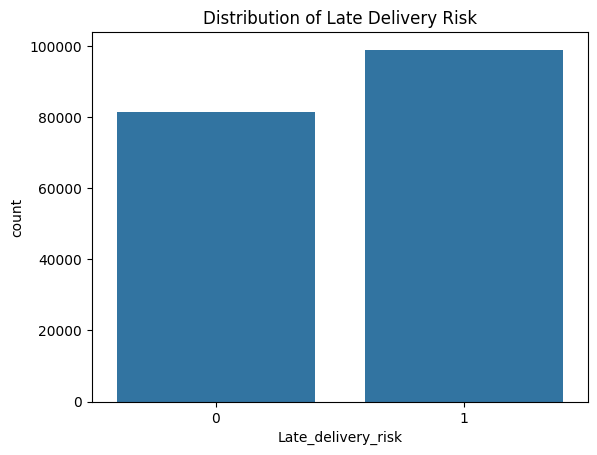

In [9]:
# Target variable analysis

print("Late_delivery_risk value counts:")
print(df['Late_delivery_risk'].value_counts())
sns.countplot(x='Late_delivery_risk', data=df)
plt.title("Distribution of Late Delivery Risk")
plt.show()

* Finding: The dataset is relatively balanced between on-time and late deliveries, showing that late delivery is a frequent and significant operational issue

In [10]:
# Identifying categorical and numerical features

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()

# Remove Late_delivery_risk from numerical columns because its y variable 
if 'Late_delivery_risk' in numerical_cols:
    numerical_cols.remove('Late_delivery_risk')

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['Order_date', 'Order_region', 'Market', 'Order_country', 'Order_state', 'Order_city', 'Delivery_status', 'Order_status', 'Payment_method', 'Shipping_mode', 'Department_name', 'Product_name', 'Product_category', 'Customer_country', 'Customer_state', 'Customer_city', 'Customer_segment', 'Order_Day', 'Order_Month']
Numerical columns: ['Order_id', 'Customer_id', 'Store_id', 'Order_total', 'Days_for_shipping', 'Days_for_shipment', 'Order_item_id', 'Product_card_id', 'Order_item_quantity', 'Order_item_product_price', 'Order_item_profit_ratio', 'Order_item_discount', 'Order_item_total', 'Product_status', 'Product_price', 'Customer_zipcode', 'Latitude', 'Longitude', 'Order_item_profit', 'Delivery_Gap', 'Profit_Margin']


## Categorical feature analysis

#### 1. Shipping Mode 

C:\Users\WELCOME\AppData\Local\Temp\ipykernel_9344\3086985700.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Shipping_mode', y='Late_delivery_risk', data=df, palette='viridis')


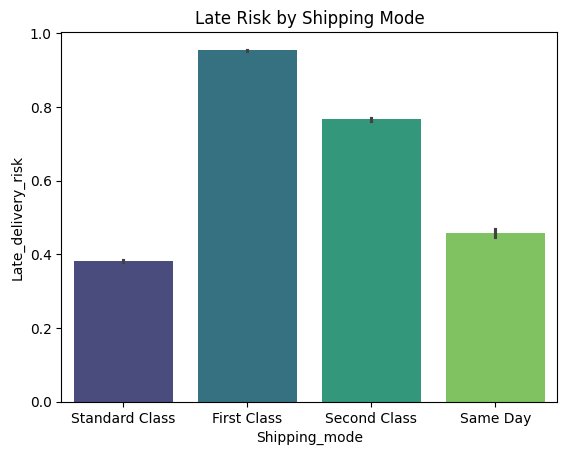

In [11]:
sns.barplot(x='Shipping_mode', y='Late_delivery_risk', data=df, palette='viridis')
plt.title('Late Risk by Shipping Mode')
plt.show()

* Higher late delivery risk is observed in First Class and Second Class shipping modes.

#### 2. Order Region 

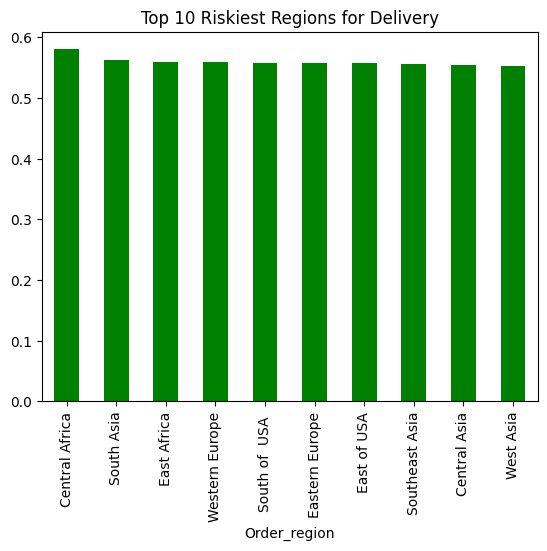

In [12]:
region_risk = df.groupby('Order_region')['Late_delivery_risk'].mean().sort_values(ascending=False).head(10)
region_risk.plot(kind='bar', color='green')
plt.title('Top 10 Riskiest Regions for Delivery')
plt.show()

* Finding: Central Africa and South Asia are the top geographic regions where deliveries are most consistently late, indicating regional supply chain weaknesses.

#### 3. Product Category 

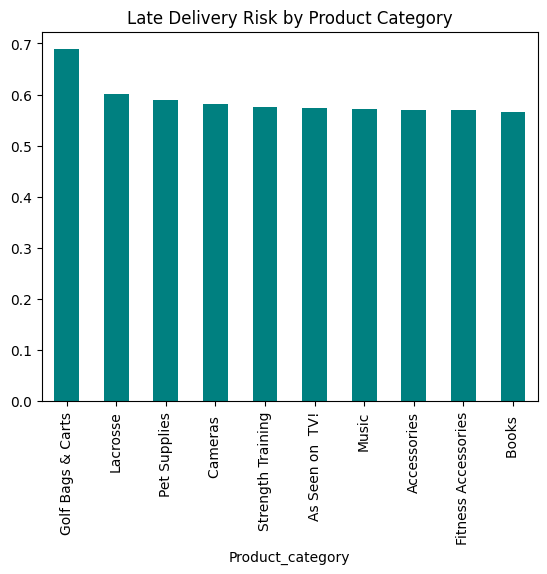

In [13]:
cat_risk = df.groupby('Product_category')['Late_delivery_risk'].mean().sort_values(ascending=False).head(10)
cat_risk.plot(kind='bar', color='teal')
plt.title('Late Delivery Risk by Product Category')
plt.show()

* Golf Bags & Carts show the highest late delivery risk (~69%), while most other product categories have a similar risk level clustered around 56–60%.

### Numerical Feature Analysis

#### 1. Delivery Gap Analysis

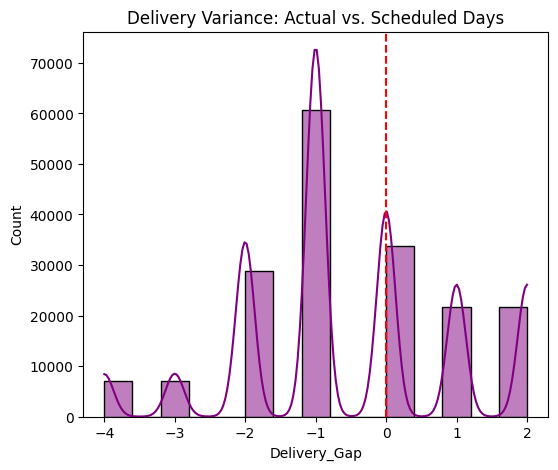

In [14]:
# Analysis of how late orders actually are
plt.figure(figsize=(6, 5))
sns.histplot(df['Delivery_Gap'], bins=15, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.title('Delivery Variance: Actual vs. Scheduled Days')
plt.show()

* Finding: Most delays cluster around a 1–2 day gap, suggesting that while the system is close to its targets, it consistently underestimates actual shipping times.

#### 2. Numerical Correlation Heatmap

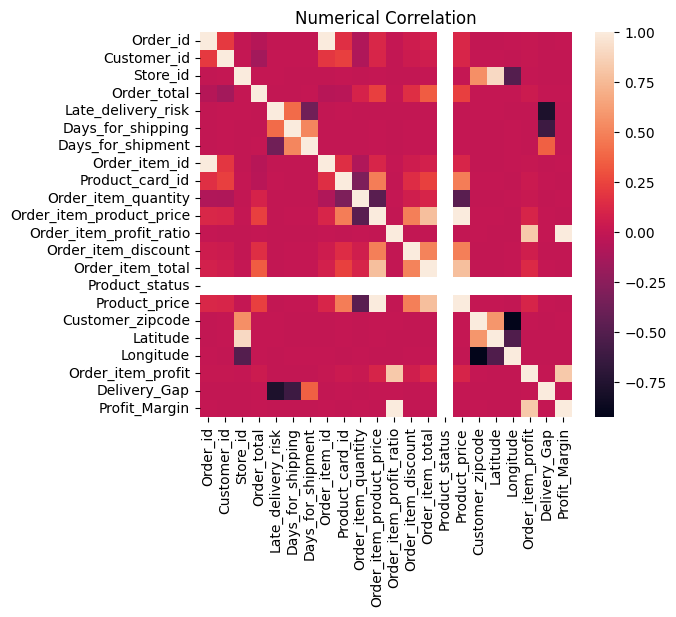

In [27]:
# Numerical columns for a focused correlation check
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(numeric_only=True))
plt.title('Numerical Correlation')
plt.show()

* Finding: The heatmap shows strong relationships between shipping time variables and order value variables, while most other features show weak correlations, indicating independent effects on late delivery risk and profitability.

#### 3. Profitability Impact

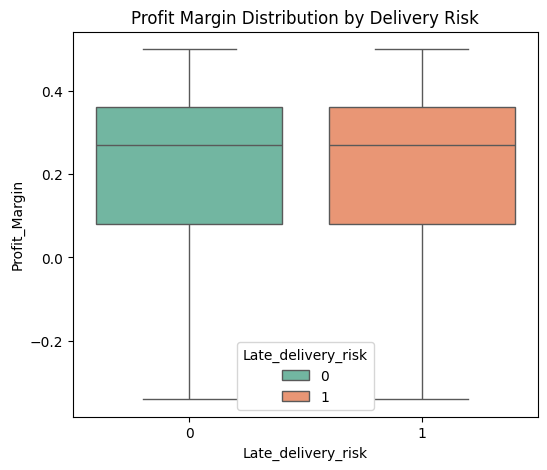

In [16]:
# Checking if late deliveries correlate with lower profit margins
plt.figure(figsize=(6, 5))
sns.boxplot(x='Late_delivery_risk', y='Profit_Margin', hue='Late_delivery_risk', data=df, showfliers=False, palette='Set2')
plt.title('Profit Margin Distribution by Delivery Risk')
plt.show()

* Finding: Profit margins remain relatively stable across both on-time and late deliveries

## Visual Analysis 

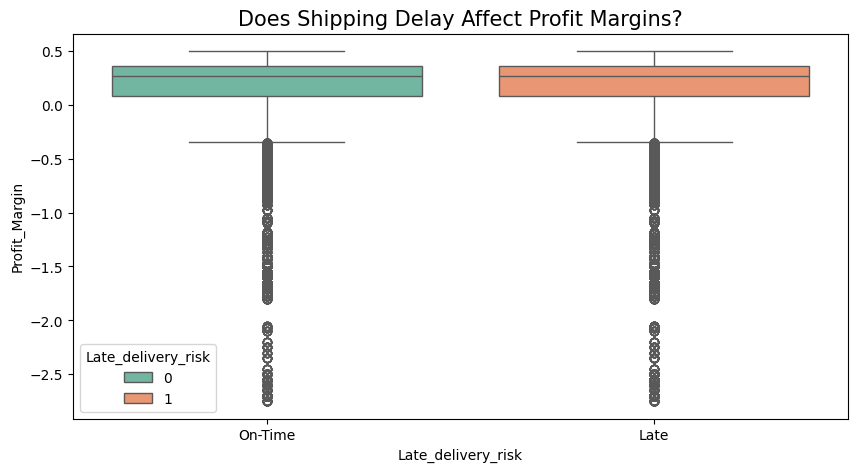

In [17]:
# Profitability vs Late Delivery
# This shows the financial impact of late shipping
plt.figure(figsize=(10, 5))
sns.boxplot(x='Late_delivery_risk', y='Profit_Margin', hue='Late_delivery_risk', data=df, palette='Set2')
plt.title('Does Shipping Delay Affect Profit Margins?', fontsize=15)
plt.xticks([0, 1], ['On-Time', 'Late'])
plt.show()

* Finding: Even after removing outliers, the median profitability remains consistent, suggesting that delivery delays are an operational failure rather than a pricing or margin issue.

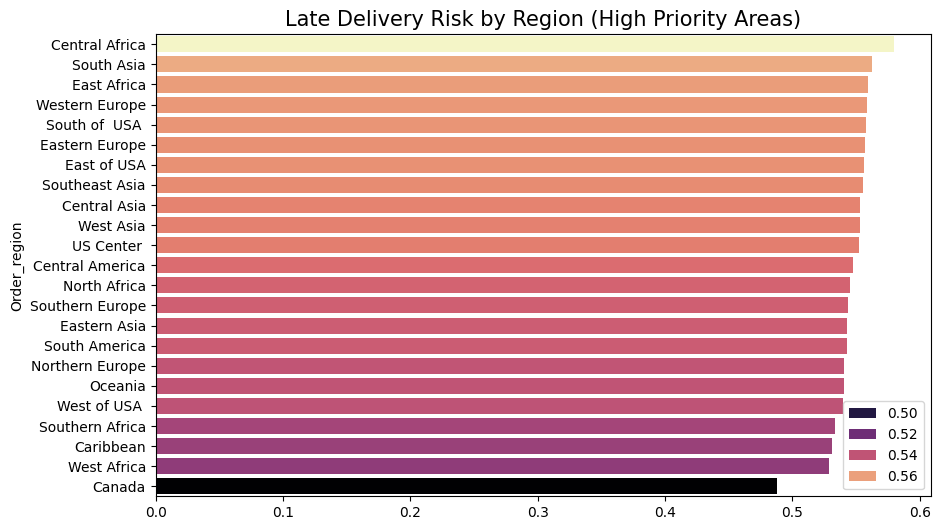

In [18]:
# Riskiest Regions
plt.figure(figsize=(10, 6))
region_risk = df.groupby('Order_region')['Late_delivery_risk'].mean().sort_values(ascending=False)
sns.barplot(x=region_risk.values, y=region_risk.index,hue=region_risk.values, palette='magma')
plt.title('Late Delivery Risk by Region (High Priority Areas)', fontsize=15)
plt.show()

* Finding: Central Africa and South Asia are the top geographic regions where deliveries are most consistently late

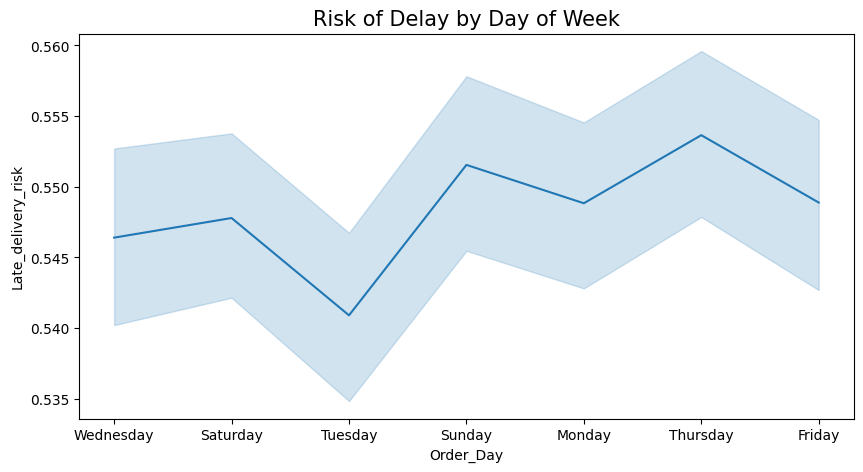

In [19]:
# Weekly Patterns
plt.figure(figsize=(10, 5))
order_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.lineplot(x='Order_Day', y='Late_delivery_risk', data=df, sort=False, estimator='mean')
plt.title('Risk of Delay by Day of Week', fontsize=15)
plt.show()

* Finding: The risk of late delivery fluctuates across the week, with certain "peak" days (often weekends or mid-week) showing higher vulnerability than others.

## KPI Calculations

In [20]:
# % of Late Deliveries
late_percent = df['Late_delivery_risk'].mean() * 100
print(f"Percentage of late deliveries: {late_percent:.2f}%")

# Average order total by region
if 'Order_total' in df.columns and 'Order_region' in df.columns:
    avg_order_by_region = df.groupby('Order_region')['Order_total'].mean()
    print("\nAverage Order Total by Region:")
    print(avg_order_by_region)

# Late Delivery % by region
if 'Order_region' in df.columns:
    region_late = df.groupby('Order_region')['Late_delivery_risk'].mean() * 100
    print("\nLate delivery percentage by region:")
    print(region_late)

# Late Delivery % by Market
if 'Market' in df.columns:
    market_late = df.groupby('Market')['Late_delivery_risk'].mean() * 100
    print("\nLate delivery percentage by Market:")
    print(market_late)

# Top product categories causing late deliveries
if 'Product_category' in df.columns:
    top_late_categories = df[df['Late_delivery_risk']==1].groupby('Product_category')['Late_delivery_risk'].count().sort_values(ascending=False)
    print("\nTop 10 product categories causing late deliveries:")
    print(top_late_categories.head(10))

Percentage of late deliveries: 54.83%

Average Order Total by Region:
Order_region
Canada             654.634689
Caribbean          647.419691
Central Africa     645.339733
Central America    661.775525
Central Asia       649.897203
East Africa        670.246860
East of USA        651.979364
Eastern Asia       568.135527
Eastern Europe     651.190966
North Africa       654.783095
Northern Europe    653.376130
Oceania            576.607238
South America      654.475828
South Asia         581.708193
South of  USA      640.126393
Southeast Asia     567.154749
Southern Africa    626.158002
Southern Europe    648.431620
US Center          651.522968
West Africa        649.274956
West Asia          646.125912
West of USA        644.524609
Western Europe     656.983936
Name: Order_total, dtype: float64

Late delivery percentage by region:
Order_region
Canada             48.800834
Caribbean          53.077663
Central Africa     57.960644
Central America    54.754596
Central Asia       55.33453